# <font color="brown">Banking Transaction Fraud Detection: Cleaning and Engineering Messy, Real-World Data </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

A bank's fraud team scores every incoming transaction for fraud risk. The data they work with
doesn't arrive as one clean table, it's assembled from three different internal systems: the
KYC/credit-bureau system (who the customer is), core banking (their accounts and transaction
history), and the transaction/device-log system (the event being scored right now, plus the
device and session it came from). Each system has its own quirks: some fields are only collected
for a subset of customers, some historical aggregates don't exist yet for brand-new accounts, and
a handful of fields are riddled with plain data-entry errors. Before any model can be trusted, this
data has to be understood, merged, cleaned, and engineered, honestly, without accidentally
scrubbing away the very extreme values that make fraud detectable in the first place.

### <font color="blue"> Objective

- Merge three separate source extracts into one analytical table and understand what the merge
  itself does to missingness.
- Diagnose *why* different columns are missing at wildly different rates (10%–90%+), across four
  distinct mechanisms, MCAR, MAR, MNAR, and merge-induced, and choose a defensible per-column
  treatment instead of one blanket rule.
- Treat outliers with judgment: prove that some "outliers" here are actually the fraud signal
  itself, and shouldn't be blindly capped away.
- Engineer a wide feature set (ratios, velocity, interactions, missingness indicators) from the
  ~190 raw columns, then thin it back down by pruning redundant, highly-correlated columns.
- Build an honestly-compared fraud model: a naive baseline (raw data, blind imputation, no
  engineering) versus the full pipeline above, evaluated on metrics that make sense at ~2% fraud
  prevalence (PR-AUC and recall-at-precision, not just ROC-AUC or accuracy).

### <font color="blue"> Data Dictionary

**`customer_profile.csv`** (KYC/credit-bureau system, one row per `Customer_ID`)
- Demographics: `Age`, `Gender`, `Marital_Status`, `Employment_Type`, `Occupation_Category`,
  `Annual_Income`, `Education_Level`, `Residential_Status`, `Years_At_Address`, `Region`,
  `Customer_Since_Days`
- Credit bureau (missing as a block when no bureau pull was made): `Credit_Bureau_Score`,
  `Delinquency_Count_24m`, `Bankruptcy_Flag`, `Num_Credit_Inquiries_6m`, `Total_Debt`,
  `Debt_To_Income_Bureau`, `Oldest_Credit_Line_Years`, `Num_Bureau_Tradelines`
- Optional KYC enrichment (mostly missing, collected only if the customer opts in):
  `Secondary_Phone`, `Alt_Email_Domain`, `LinkedIn_Verified`, `Referral_Code`,
  `Social_Media_Score`, `Preferred_Language`, `Secondary_Address_City`,
  `Emergency_Contact_Provided`, `Marketing_Opt_In_Channel`, `Employer_Verified_Source`

**`account_summary.csv`** (core banking system, one row per `Customer_ID` **who has synced**)
- Account info: `Account_Age_Days`, `Account_Type`, balances, `Credit_Limit`,
  `Credit_Utilization`, `Overdraft_Count_90d`, `Num_Products_Held`, `Num_Linked_Accounts`,
  `Savings_Rate`, `Statement_Cycle_Day`, `Autopay_Enabled_Flag`
- Transaction-window aggregates: `Txn_{Count|Sum|Avg|Max}_{1h|24h|7d|30d|90d}_{ATM|POS|Online|
  Wire|International|All}` — ~120 columns of rolling activity, the 30d/90d ones don't exist yet
  for accounts younger than that window.

**`transaction_events.csv`** (transaction/device-log system, one row per `Customer_ID`, always
present — this is the specific event being scored)
- Target: `Is_Fraud` (1 = fraudulent)
- Device/behavioral: `Num_Devices_90d`, `New_Device_Flag`, `Failed_Login_Count_24h`,
  `Login_Count_24h`, `Session_Duration_Avg_Sec`, `IP_Country_Mismatch_Flag`,
  `Distance_From_Home_Km`, `Password_Reset_Count_90d`, `Browser_Change_Flag`,
  `VPN_Detected_Flag` (behavioral signals are only captured for digital channels)
- Current transaction: `Transaction_Amount`, `Transaction_Channel`, `Merchant_Category`,
  `Merchant_Risk_Score`, `Is_Foreign_Transaction`, `Transaction_Hour`, `Is_Weekend`,
  `Time_Since_Last_Transaction_Min`, `Transaction_Currency`, `Card_Present_Flag`

## <font color="brown"> Importing Necessary Libraries</font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", 60)
%matplotlib inline

## <font color="brown"> Reading and Merging the Three Extracts</font>

In [2]:
customer_profile = pd.read_csv("customer_profile.csv")
account_summary = pd.read_csv("account_summary.csv")
transaction_events = pd.read_csv("transaction_events.csv")

print("customer_profile:", customer_profile.shape)
print("account_summary: ", account_summary.shape)
print("transaction_events:", transaction_events.shape)

customer_profile: (100000, 30)
account_summary:  (97688, 136)
transaction_events: (100000, 22)


`account_summary.csv` already has noticeably fewer rows than the other two, that's not a mistake,
it's customers whose account hasn't yet synced to the core banking extract. Confirming there are
no duplicate keys before merging (a merge onto a duplicated key would silently multiply rows):

In [3]:
for name, d in [("customer_profile", customer_profile), ("account_summary", account_summary),
                ("transaction_events", transaction_events)]:
    print(name, "duplicate Customer_IDs:", d["Customer_ID"].duplicated().sum())

customer_profile duplicate Customer_IDs: 0
account_summary duplicate Customer_IDs: 0
transaction_events duplicate Customer_IDs: 0


`transaction_events` is the base (it always exists, one row per event being scored, and carries
the target), left-joined with the other two on `Customer_ID`:

In [4]:
df = (
    transaction_events
    .merge(customer_profile, on="Customer_ID", how="left")
    .merge(account_summary, on="Customer_ID", how="left")
)
print("Merged shape:", df.shape)
assert len(df) == len(transaction_events), "merge should not change row count"

Merged shape: (100000, 186)


How much of the missingness in the merged table comes purely from the join itself, i.e. from
`account_summary` rows that never existed, versus missingness that was already present within a
single source file?

In [5]:
account_cols = [c for c in account_summary.columns if c != "Customer_ID"]
rows_missing_whole_account = df[account_cols].isnull().all(axis=1).sum()
customers_without_account_row = transaction_events["Customer_ID"].isin(
    set(transaction_events["Customer_ID"]) - set(account_summary["Customer_ID"])
).sum()

print("Rows with every account_summary column NaN:", rows_missing_whole_account)
print("Customers absent from account_summary.csv entirely:", customers_without_account_row)
print("These match:", rows_missing_whole_account == customers_without_account_row)
print(f"That's {rows_missing_whole_account / len(df):.2%} of all rows, a merge-induced")
print("missingness mechanism layered on top of each source file's own internal missingness.")

Rows with every account_summary column NaN: 2312
Customers absent from account_summary.csv entirely: 2312
These match: True
That's 2.31% of all rows, a merge-induced
missingness mechanism layered on top of each source file's own internal missingness.


## <font color="brown"> First Look at the Merged Data</font>

In [6]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes.value_counts())
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df["Is_Fraud"].value_counts(normalize=True).round(4)

Shape: (100000, 186)

Dtypes:
 float64    155
str         18
int64       13
Name: count, dtype: int64



Memory usage: 220.5 MB


Is_Fraud
0    0.979
1    0.021
Name: proportion, dtype: float64

## <font color="brown"> The Missingness Landscape</font>

In [7]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

print(f"{len(missing_pct)} of {df.shape[1]} columns have at least one missing value.")
print(f"Missing %% ranges from {missing_pct.min():.1%} to {missing_pct.max():.1%}.")

tiers = pd.cut(missing_pct, bins=[0, 0.05, 0.15, 0.35, 0.60, 1.0],
               labels=["0-5%", "5-15%", "15-35%", "35-60%", "60-100%"])
tiers.value_counts().sort_index()

158 of 186 columns have at least one missing value.
Missing %% ranges from 2.3% to 91.1%.


0-5%        33
5-15%      102
15-35%       1
35-60%      12
60-100%     10
Name: count, dtype: int64

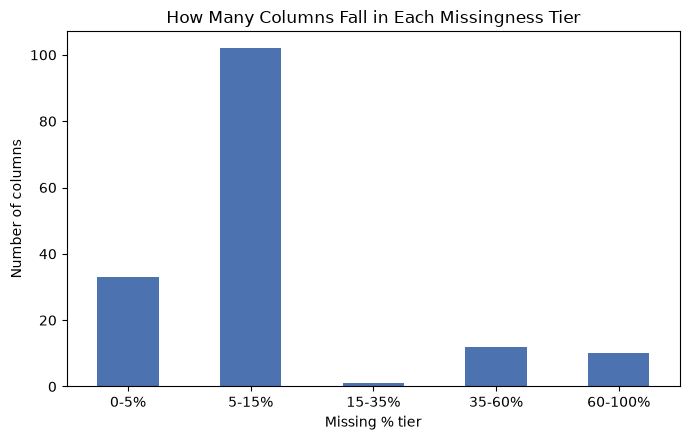

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
tiers.value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Number of columns")
ax.set_xlabel("Missing % tier")
ax.set_title("How Many Columns Fall in Each Missingness Tier")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

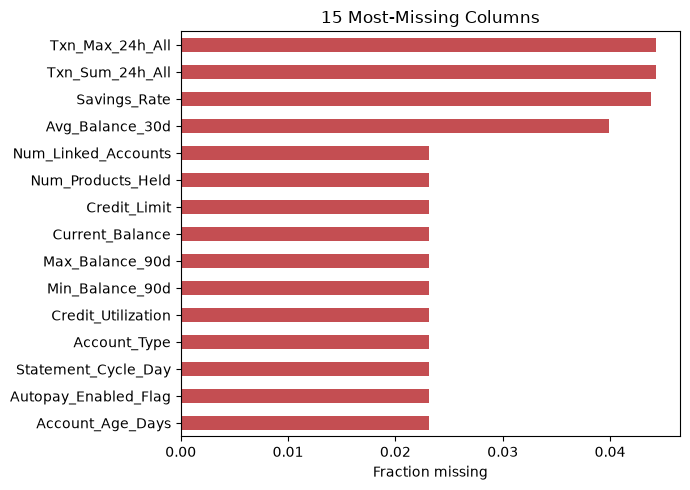

In [9]:
missing_pct.tail(15).sort_values().plot(
    kind="barh", figsize=(7, 5), color="#C44E52", title="15 Most-Missing Columns"
)
plt.xlabel("Fraction missing")
plt.tight_layout()
plt.show()

### <font color="blue"> Confirming Why: MCAR, MAR, MNAR, and Merge-Induced</font>

**MAR, explained by an observed column (`Account_Age_Days`)**: the 30d/90d transaction aggregates
shouldn't exist yet for accounts younger than that window. If that's really what's driving the
missingness, the missing rate should jump sharply at the 30/90-day boundary:

In [10]:
age_bins = pd.cut(df["Account_Age_Days"], bins=[0, 29, 89, np.inf], labels=["<30d", "30-89d", "90d+"])
mar_check = pd.DataFrame({
    "Txn_Count_30d_All missing": df.groupby(age_bins, observed=True)["Txn_Count_30d_All"].apply(lambda s: s.isnull().mean()),
    "Txn_Count_90d_All missing": df.groupby(age_bins, observed=True)["Txn_Count_90d_All"].apply(lambda s: s.isnull().mean()),
}).round(3)
mar_check

,Txn_Count_30d_All missing,Txn_Count_90d_All missing
Account_Age_Days,,
<30d,1.0,1.0
30-89d,0.0,1.0
90d+,0.0,0.0


Exactly as expected: `Txn_Count_30d_All` is missing for essentially every account under 30 days
old and present otherwise, `Txn_Count_90d_All` follows the same pattern at the 90-day mark. This
is a textbook **MAR** case, missing *because of* a fully-observed column, not randomly, and not
because of the (unobserved) value itself.

**Merge-induced MAR**: is the merge-omission random, or explainable? `Customer_Since_Days` (from
`customer_profile`, always observed) should predict it, newer customers are more likely to not
yet be synced to core banking:

In [11]:
tenure_bins = pd.cut(df["Customer_Since_Days"], bins=[0, 30, 90, 365, np.inf],
                      labels=["<30d", "30-90d", "90-365d", "365d+"])
df.groupby(tenure_bins, observed=True)["Account_Age_Days"].apply(lambda s: s.isnull().mean()).round(3)

Customer_Since_Days
<30d       0.173
30-90d     0.113
90-365d    0.025
365d+      0.001
Name: Account_Age_Days, dtype: float64

Confirmed, the merge-induced gap is heavily concentrated among the newest customers, not spread
uniformly. Also explainable, also MAR, just at the row level rather than a single-column level.

**MNAR: `Annual_Income`**. Missingness here correlates with `Employment_Type` (an observed
column), but by construction it *also* depends on the income value itself, lower earners
under-report more, regardless of employment type. The employment-type pattern below is visible and
testable; the income-level dependence is not, that's precisely what makes MNAR harder to handle
than MAR: you can't fully explain or correct for it using only the columns you can see.

In [12]:
df.groupby("Employment_Type")["Annual_Income"].apply(lambda s: s.isnull().mean()).sort_values(ascending=False).round(3)

Employment_Type
Unemployed       0.279
Student          0.272
Self-Employed    0.215
Retired          0.150
Salaried         0.109
Name: Annual_Income, dtype: float64

**MCAR: the optional KYC fields**. `Secondary_Phone`, `LinkedIn_Verified`, `Referral_Code`, and
similar fields are simply optional at onboarding, whether a given customer filled them in has no
relationship to their fraud risk, income, or anything else in the data, it's missing by design,
close to pure MCAR (Missing Completely At Random).

## <font color="brown"> Splitting Before Fitting Any Treatment</font>

Everything above was understanding the raw, merged data, missingness mechanisms are a property of
how the data was collected, not something that depends on a train/test split. Everything from here
on is different: every imputed value, outlier fence, frequency-encoding map, and correlation-based
column drop below gets baked into the features the model actually sees. From this point forward,
every one of those statistics is fit on the training split **only**, and applied unchanged to
validation and test, the same no-leakage discipline as the threshold tuning later in this
notebook, just applied one step earlier, to preprocessing rather than only the classification
threshold.

In [13]:
train_full_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=1, stratify=df["Is_Fraud"])
train_idx, val_idx = train_test_split(
    train_full_idx, test_size=0.25, random_state=1, stratify=df.loc[train_full_idx, "Is_Fraud"]
)
df_train = df.loc[train_idx].copy()
df_val = df.loc[val_idx].copy()
df_test = df.loc[test_idx].copy()

for name, frame in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name}: n={len(frame):,}, fraud rate={frame['Is_Fraud'].mean():.4f}")

train: n=60,000, fraud rate=0.0210
val: n=20,000, fraud rate=0.0210
test: n=20,000, fraud rate=0.0210


## <font color="brown"> Missing-Data Strategy</font>

Four mechanisms, four different honest treatments, not one blanket rule:

1. **Near-unique identifier-like fields** (`Secondary_Phone`, `Referral_Code`): dropped outright,
   not because they're missing, but because even where present they're not usable as raw model
   features (near-unique per row).
2. **High-missingness numeric fields carrying real signal when present** (bureau block,
   `Annual_Income`): add a `_was_missing` indicator *before* imputing, since the act of being
   missing may itself be informative, then impute the value.
3. **High-missingness categorical fields**: fill with an explicit `"Missing"` category rather than
   a mode, missingness here is a legitimate state, not noise to erase.
4. **Low/medium-missingness numeric fields** (transaction aggregates, account info): impute with
   the median, transaction data is skewed enough that a blind mean would be pulled around by the
   very outliers discussed next.

All of the statistics below (which columns count as "high missing", the medians themselves) are
computed on `df_train` only:

In [14]:
id_like_cols = ["Secondary_Phone", "Referral_Code"]
numeric_cols = [c for c in df_train.select_dtypes(include=np.number).columns
                if c not in ["Customer_ID", "Is_Fraud"]]
categorical_cols = df_train.select_dtypes(include="object").columns.tolist()

missing_frac_train = df_train[numeric_cols].isnull().mean()
high_missing_numeric = missing_frac_train[missing_frac_train > 0.15].index.tolist()
print(f"{len(high_missing_numeric)} numeric columns above 15% missing (training split) get a _was_missing flag:")
print(high_missing_numeric)

16 numeric columns above 15% missing (training split) get a _was_missing flag:
['Num_Devices_90d', 'Session_Duration_Avg_Sec', 'Browser_Change_Flag', 'VPN_Detected_Flag', 'Annual_Income', 'Credit_Bureau_Score', 'Delinquency_Count_24m', 'Bankruptcy_Flag', 'Num_Credit_Inquiries_6m', 'Total_Debt', 'Debt_To_Income_Bureau', 'Oldest_Credit_Line_Years', 'Num_Bureau_Tradelines', 'LinkedIn_Verified', 'Social_Media_Score', 'Emergency_Contact_Provided']


C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\3456748415.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_train.select_dtypes(include="object").columns.tolist()


For `Annual_Income` specifically, a group-wise median (by `Employment_Type`), fit on the training
split, is more honest than a single global median, a Student's typical income and a Salaried
employee's typical income aren't the same number:

In [15]:
median_fill = df_train[numeric_cols].median()
income_median_by_group = df_train.groupby("Employment_Type")["Annual_Income"].median()
global_income_median = df_train["Annual_Income"].median()
print("Training-split median income by employment type:")
income_median_by_group.round(0)

Training-split median income by employment type:


Employment_Type
Retired          30708.0
Salaried         55333.0
Self-Employed    63728.0
Student           5481.0
Unemployed        8106.0
Name: Annual_Income, dtype: float64

In [16]:
def apply_missing_strategy(frame):
    frame = frame.drop(columns=id_like_cols)
    for c in high_missing_numeric:
        frame[f"{c}_was_missing"] = frame[c].isnull().astype(int)
    frame["Annual_Income"] = frame["Annual_Income"].fillna(
        frame["Employment_Type"].map(income_median_by_group).fillna(global_income_median)
    )
    for c in numeric_cols:
        if c == "Annual_Income":
            continue
        if frame[c].isnull().any():
            frame[c] = frame[c].fillna(median_fill[c])
    for c in categorical_cols:
        if c in frame.columns:
            frame[c] = frame[c].fillna("Missing")
    return frame

df_train_clean = apply_missing_strategy(df_train)
df_val_clean = apply_missing_strategy(df_val)
df_test_clean = apply_missing_strategy(df_test)

print("Remaining missing values -- train:", df_train_clean.isnull().sum().sum(),
      " val:", df_val_clean.isnull().sum().sum(),
      " test:", df_test_clean.isnull().sum().sum())

Remaining missing values -- train: 0  val: 0  test: 0


## <font color="brown"> Outliers: Not All of Them Are Noise</font>

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\3703861164.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df_train["Transaction_Amount"], vert=False)


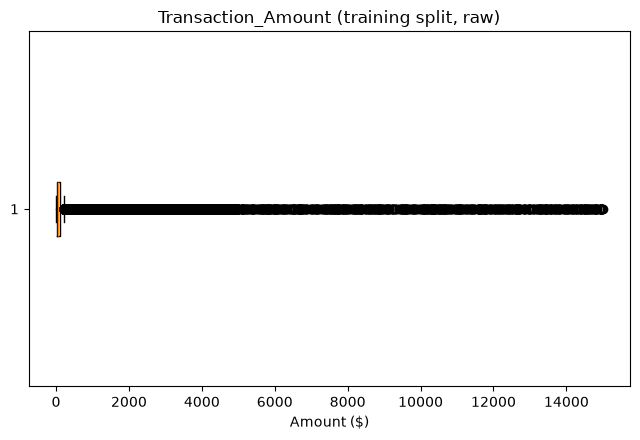

count    60000.00
mean       251.21
std       1180.32
min          0.50
25%         30.51
50%         55.55
75%        103.47
max      14994.93
Name: Transaction_Amount, dtype: float64

In [17]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.boxplot(df_train["Transaction_Amount"], vert=False)
ax.set_title("Transaction_Amount (training split, raw)")
ax.set_xlabel("Amount ($)")
plt.tight_layout()
plt.show()
df_train["Transaction_Amount"].describe().round(2)

In [18]:
q1, q3 = df_train["Transaction_Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
hi_fence = q3 + 1.5 * iqr
lo_fence = df_train["Transaction_Amount"].quantile(0.01)

above = df_train["Transaction_Amount"] > hi_fence
below = df_train["Transaction_Amount"] <= lo_fence

outlier_summary = pd.DataFrame({
    "n_rows": [above.sum(), below.sum(), (~above & ~below).sum()],
    "fraud_rate": [df_train.loc[above, "Is_Fraud"].mean(), df_train.loc[below, "Is_Fraud"].mean(),
                   df_train.loc[~above & ~below, "Is_Fraud"].mean()],
}, index=["Above IQR high fence", "Bottom 1 percentile", "Everything else"]).round(4)
outlier_summary

,n_rows,fraud_rate
Above IQR high fence,5163,0.0864
Bottom 1 percentile,602,0.4236
Everything else,54235,0.0103


In [19]:
total_fraud = df_train["Is_Fraud"].sum()
fraud_in_tails = df_train.loc[above | below, "Is_Fraud"].sum()
print(f"Fences (fit on the training split only): IQR high fence ${hi_fence:,.2f}, "
      f"bottom 1st percentile ${lo_fence:,.2f}")
print(f"{above.sum() + below.sum():,} rows ({(above | below).mean():.1%} of the training split) sit in these two tails.")
print(f"They contain {fraud_in_tails:,} of {total_fraud:,} training-split fraud cases "
      f"({fraud_in_tails / total_fraud:.1%} of all training-split fraud).")

Fences (fit on the training split only): IQR high fence $212.91, bottom 1st percentile $3.91
5,765 rows (9.6% of the training split) sit in these two tails.
They contain 701 of 1,258 training-split fraud cases (55.7% of all training-split fraud).


**Blindly capping or removing `Transaction_Amount` outliers would delete a large share of the
fraud signal along with the noise.** The bottom-1%-percentile "card testing" pattern and the
top-tail "cash-out" pattern are both far more fraud-prone than the bulk of the data, this is
exactly the situation where naive outlier treatment actively hurts a fraud model. Instead of
capping the amount, its *extremity* becomes a feature (fence fit on train, applied to all three
splits):

In [20]:
def add_extreme_amount_flag(frame):
    frame["Is_Extreme_Amount"] = (
        (frame["Transaction_Amount"] > hi_fence) | (frame["Transaction_Amount"] <= lo_fence)
    ).astype(int)
    return frame

df_train_clean = add_extreme_amount_flag(df_train_clean)
df_val_clean = add_extreme_amount_flag(df_val_clean)
df_test_clean = add_extreme_amount_flag(df_test_clean)
df_train_clean.groupby("Is_Extreme_Amount")["Is_Fraud"].mean().round(4)

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\2949219290.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["Is_Extreme_Amount"] = (
C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\2949219290.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["Is_Extreme_Amount"] = (
C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\2949219290.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

Is_Extreme_Amount
0    0.0103
1    0.1216
Name: Is_Fraud, dtype: float64

`Age` and `Annual_Income`, on the other hand, contain genuine data-entry errors (negative age,
ages over 100, non-positive income), unlike the transaction-amount tails, these extremes carry no
fraud signal, they're just noise, and are safe to clip. Note the distinction from a business-policy
floor: a handful of customers are legitimately under 18 in the raw distribution, that's not an
error, it's clipped separately below as a minimum-banking-age business rule, not "cleaning". Both
bounds are fixed business constants, not fit from data, so applying them identically to all three
splits carries no leakage risk:

In [21]:
print("Age range in training split before cleaning:", df_train["Age"].min(), "to", df_train["Age"].max())
print("Rows with a clearly impossible age (<0 or >100):", ((df_train["Age"] < 0) | (df_train["Age"] > 100)).sum())
print("Rows naturally under 18 (not an error, just young):",
      ((df_train["Age"] >= 0) & (df_train["Age"] < 18)).sum())
print("Rows with non-positive income:", (df_train["Annual_Income"] <= 0).sum())

for frame in (df_train_clean, df_val_clean, df_test_clean):
    frame["Age"] = frame["Age"].clip(18, 100)          # 18 = minimum banking age policy, 100 = error cap
    frame["Annual_Income"] = frame["Annual_Income"].clip(lower=1000)

Age range in training split before cleaning: -9 to 200
Rows with a clearly impossible age (<0 or >100): 115
Rows naturally under 18 (not an error, just young): 1733
Rows with non-positive income: 45


## <font color="brown"> Feature Engineering at Scale</font>

### <font color="blue"> Ratio Features</font>

In [22]:
def add_ratio_features(frame):
    frame["Amount_to_Balance_Ratio"] = frame["Transaction_Amount"] / (frame["Avg_Balance_90d"] + 1)
    frame["Amount_to_Limit_Ratio"] = frame["Transaction_Amount"] / (frame["Credit_Limit"] + 1)
    return frame

df_train_clean = add_ratio_features(df_train_clean)
df_val_clean = add_ratio_features(df_val_clean)
df_test_clean = add_ratio_features(df_test_clean)
df_train_clean[["Amount_to_Balance_Ratio", "Amount_to_Limit_Ratio"]].describe().round(3)

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\3479175658.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["Amount_to_Balance_Ratio"] = frame["Transaction_Amount"] / (frame["Avg_Balance_90d"] + 1)
C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\3479175658.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["Amount_to_Limit_Ratio"] = frame["Transaction_Amount"] / (frame["Credit_Limit"] + 1)


,Amount_to_Balance_Ratio,Amount_to_Limit_Ratio
count,60000.000,60000.000
mean,1.641,0.061
std,16.994,0.334
min,0.000,0.000
25%,0.118,0.005
50%,0.231,0.011
75%,0.455,0.024
max,2191.190,14.285


### <font color="blue"> Velocity: Short-Window Rate vs. the Customer's Own Long-Run Baseline</font>

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\1655713602.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["Velocity_1h_vs_90d"] = frame["Txn_Count_1h_All"] / hourly_rate_90d


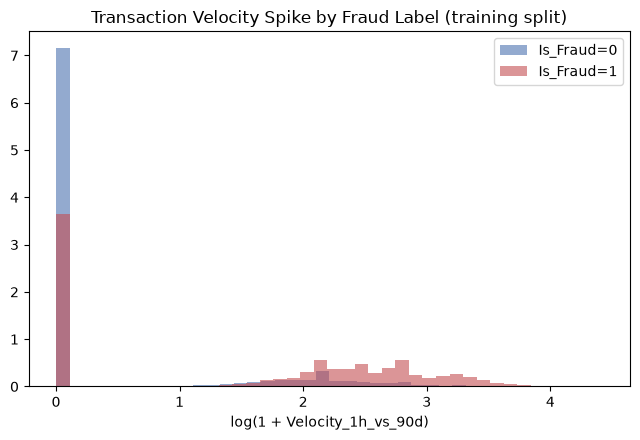

In [23]:
def add_velocity_feature(frame):
    hourly_rate_90d = frame["Txn_Count_90d_All"] / (90 * 24) + 1e-4
    frame["Velocity_1h_vs_90d"] = frame["Txn_Count_1h_All"] / hourly_rate_90d
    return frame

df_train_clean = add_velocity_feature(df_train_clean)
df_val_clean = add_velocity_feature(df_val_clean)
df_test_clean = add_velocity_feature(df_test_clean)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, color in [(0, "#4C72B0"), (1, "#C44E52")]:
    subset = df_train_clean.loc[df_train_clean["Is_Fraud"] == label, "Velocity_1h_vs_90d"]
    ax.hist(np.log1p(subset), bins=40, alpha=0.6, color=color, label=f"Is_Fraud={label}", density=True)
ax.set_xlabel("log(1 + Velocity_1h_vs_90d)")
ax.set_title("Transaction Velocity Spike by Fraud Label (training split)")
ax.legend()
plt.tight_layout()
plt.show()

### <font color="blue"> Interaction Flags</font>

In [24]:
def add_interaction_flags(frame):
    frame["New_Device_and_Foreign"] = frame["New_Device_Flag"] * frame["Is_Foreign_Transaction"]
    frame["OddHour_and_ExtremeAmount"] = (frame["Transaction_Hour"] <= 4).astype(int) * frame["Is_Extreme_Amount"]
    return frame

df_train_clean = add_interaction_flags(df_train_clean)
df_val_clean = add_interaction_flags(df_val_clean)
df_test_clean = add_interaction_flags(df_test_clean)

interaction_check = pd.DataFrame({
    "New_Device_and_Foreign": df_train_clean.groupby("New_Device_and_Foreign")["Is_Fraud"].mean(),
    "OddHour_and_ExtremeAmount": df_train_clean.groupby("OddHour_and_ExtremeAmount")["Is_Fraud"].mean(),
}).round(4)
interaction_check

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\1415721771.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["New_Device_and_Foreign"] = frame["New_Device_Flag"] * frame["Is_Foreign_Transaction"]
C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\1415721771.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["OddHour_and_ExtremeAmount"] = (frame["Transaction_Hour"] <= 4).astype(int) * frame["Is_Extreme_Amount"]
C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\1415721771.py:2: PerformanceWarning: DataFrame is high

,New_Device_and_Foreign,OddHour_and_ExtremeAmount
0,0.0180,0.0135
1,0.1793,0.2146


### <font color="blue"> Frequency Encoding for a High-Cardinality Categorical</font>

In [25]:
merchant_freq = df_train_clean["Merchant_Category"].value_counts(normalize=True)

def add_merchant_freq(frame):
    frame["Merchant_Category_Freq"] = frame["Merchant_Category"].map(merchant_freq).fillna(0)
    return frame

df_train_clean = add_merchant_freq(df_train_clean)
df_val_clean = add_merchant_freq(df_val_clean)
df_test_clean = add_merchant_freq(df_test_clean)
df_train_clean.groupby("Merchant_Category")["Is_Fraud"].mean().sort_values(ascending=False).round(4)

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\1672705723.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  frame["Merchant_Category_Freq"] = frame["Merchant_Category"].map(merchant_freq).fillna(0)


Merchant_Category
Grocery          0.0228
Online Retail    0.0224
Restaurant       0.0223
Utilities        0.0219
Other            0.0203
Travel           0.0200
Electronics      0.0163
Cash Advance     0.0160
Name: Is_Fraud, dtype: float64

## <font color="brown"> Dimensionality Thinning</font>

Many of the ~120 transaction-window aggregate columns are, by construction, near-duplicates of
each other (a 90d count is highly correlated with a 30d count for the same channel). "~190 raw
columns" does not mean "~190 independent signals", pruning the redundant ones keeps the model
lean without losing information. Which columns count as redundant is decided on the training split
only:

In [26]:
agg_numeric = [c for c in df_train_clean.columns if c.startswith("Txn_")]
corr = df_train_clean[agg_numeric].corr().abs()

to_drop = set()
cols = corr.columns.tolist()
for i, c1 in enumerate(cols):
    if c1 in to_drop:
        continue
    for c2 in cols[i + 1:]:
        if c2 in to_drop:
            continue
        if corr.loc[c1, c2] > 0.95:
            # keep the one with fewer missing values in the original (pre-imputation) training data
            if df_train[c1].isnull().sum() <= df_train[c2].isnull().sum():
                to_drop.add(c2)
            else:
                to_drop.add(c1)
                break

print(f"{len(to_drop)} of {len(agg_numeric)} transaction-aggregate columns dropped as redundant "
      f"(|corr| > 0.95, decided on the training split).")
df_train_thin = df_train_clean.drop(columns=list(to_drop))
df_val_thin = df_val_clean.drop(columns=list(to_drop))
df_test_thin = df_test_clean.drop(columns=list(to_drop))
print("Shape before thinning:", df_train_clean.shape, " after thinning:", df_train_thin.shape)

17 of 120 transaction-aggregate columns dropped as redundant (|corr| > 0.95, decided on the training split).
Shape before thinning: (60000, 207)  after thinning: (60000, 190)


In [27]:
near_constant = [c for c in df_train_thin.select_dtypes(include=np.number).columns
                  if c not in ["Customer_ID", "Is_Fraud"] and df_train_thin[c].std() < 1e-6]
print("Near-zero-variance columns dropped (fit on train):", near_constant)
df_train_thin = df_train_thin.drop(columns=near_constant)
df_val_thin = df_val_thin.drop(columns=near_constant)
df_test_thin = df_test_thin.drop(columns=near_constant)
print("Final shape after dimensionality thinning:", df_train_thin.shape)

Near-zero-variance columns dropped (fit on train): []
Final shape after dimensionality thinning: (60000, 190)


## <font color="brown"> Modeling</font>

Two pipelines, both fit exclusively on `df_train` and applied unchanged to `df_val`/`df_test`,
compared honestly:

- **Naive**: blind training-mean imputation, no missingness indicators, no outlier treatment, no
  engineered ratio/velocity/interaction features, no correlation pruning, the ~190 raw columns
  handled with the least amount of thought possible.
- **Thoughtful**: everything built above, indicator flags, group-aware imputation, outlier
  feature-ization instead of blind capping, engineered features, correlation-pruned column set.

Both use the same classifier and the exact same row-level train/validation/test split, so any
performance difference is attributable to the data preparation, not the algorithm or the split.

In [28]:
drop_always = ["Customer_ID", "Is_Fraud", "Secondary_Phone", "Referral_Code"]

# --- Naive pipeline: every statistic fit on df_train only ---
naive_numeric_cols = [c for c in df_train.select_dtypes(include=np.number).columns
                       if c not in ["Customer_ID", "Is_Fraud"]]
naive_categorical_cols = [c for c in df_train.select_dtypes(include="object").columns if c not in drop_always]
naive_mean_fill = df_train[naive_numeric_cols].mean()

def naive_prep(frame):
    frame = frame.drop(columns=[c for c in drop_always if c in frame.columns]).copy()
    num_cols = [c for c in naive_numeric_cols if c in frame.columns]
    frame[num_cols] = frame[num_cols].fillna(naive_mean_fill[num_cols])
    cat_cols = [c for c in naive_categorical_cols if c in frame.columns]
    frame[cat_cols] = frame[cat_cols].fillna("Missing")
    return frame

naive_train, naive_val, naive_test = naive_prep(df_train), naive_prep(df_val), naive_prep(df_test)

Xn_train = pd.get_dummies(naive_train, columns=naive_categorical_cols, drop_first=True, dtype=int)
Xn_val = pd.get_dummies(naive_val, columns=naive_categorical_cols, drop_first=True, dtype=int).reindex(
    columns=Xn_train.columns, fill_value=0)
Xn_test = pd.get_dummies(naive_test, columns=naive_categorical_cols, drop_first=True, dtype=int).reindex(
    columns=Xn_train.columns, fill_value=0)

yn_train, yn_val, yn_test = df_train["Is_Fraud"], df_val["Is_Fraud"], df_test["Is_Fraud"]
print("Naive feature matrix (train):", Xn_train.shape)

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\3802760893.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  naive_categorical_cols = [c for c in df_train.select_dtypes(include="object").columns if c not in drop_always]


Naive feature matrix (train): (60000, 221)


In [29]:
# --- Thoughtful pipeline: already fit on df_train via df_*_thin above ---
thoughtful_categorical_cols = df_train_thin.select_dtypes(include="object").columns.tolist()

thoughtful_train = df_train_thin.drop(columns=[c for c in drop_always if c in df_train_thin.columns])
thoughtful_val = df_val_thin.drop(columns=[c for c in drop_always if c in df_val_thin.columns])
thoughtful_test = df_test_thin.drop(columns=[c for c in drop_always if c in df_test_thin.columns])

Xt_train = pd.get_dummies(thoughtful_train, columns=thoughtful_categorical_cols, drop_first=True, dtype=int)
Xt_val = pd.get_dummies(thoughtful_val, columns=thoughtful_categorical_cols, drop_first=True, dtype=int).reindex(
    columns=Xt_train.columns, fill_value=0)
Xt_test = pd.get_dummies(thoughtful_test, columns=thoughtful_categorical_cols, drop_first=True, dtype=int).reindex(
    columns=Xt_train.columns, fill_value=0)

yt_train, yt_val, yt_test = df_train["Is_Fraud"], df_val["Is_Fraud"], df_test["Is_Fraud"]

print("Thoughtful feature matrix (train):", Xt_train.shape)
for name, arr in [("train", yt_train), ("val", yt_val), ("test", yt_test)]:
    print(f"{name}: n={len(arr)}, fraud rate={arr.mean():.4f}")

C:\Users\yoges\AppData\Local\Temp\ipykernel_37516\4191243305.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  thoughtful_categorical_cols = df_train_thin.select_dtypes(include="object").columns.tolist()


Thoughtful feature matrix (train): (60000, 227)
train: n=60000, fraud rate=0.0210
val: n=20000, fraud rate=0.0210
test: n=20000, fraud rate=0.0210


In [30]:
def fit_gb(X_train, y_train):
    weights = compute_sample_weight(class_weight="balanced", y=y_train)
    clf = GradientBoostingClassifier(
        n_estimators=150, max_depth=3, learning_rate=0.08, subsample=0.8, random_state=1
    )
    clf.fit(X_train, y_train, sample_weight=weights)
    return clf

def evaluate(clf, X_test, y_test, threshold=0.5):
    proba = clf.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    }, proba

gb_naive = fit_gb(Xn_train, yn_train)
gb_thoughtful = fit_gb(Xt_train, yt_train)

metrics_naive, proba_naive = evaluate(gb_naive, Xn_test, yn_test)
metrics_thoughtful, proba_thoughtful = evaluate(gb_thoughtful, Xt_test, yt_test)

comparison = pd.DataFrame([metrics_naive, metrics_thoughtful], index=["Naive", "Thoughtful"]).round(4)
comparison

,ROC-AUC,PR-AUC,Recall,Precision,F1
Naive,0.9797,0.7320,0.9238,0.2957,0.4480
Thoughtful,0.9800,0.7236,0.9190,0.2940,0.4455


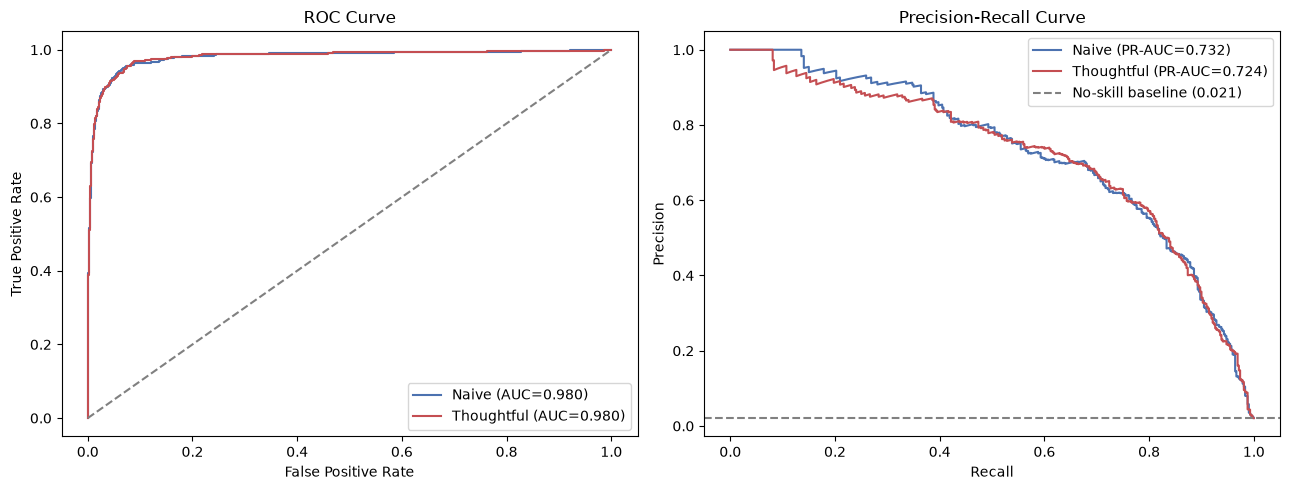

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr_n, tpr_n, _ = roc_curve(yn_test, proba_naive)
fpr_t, tpr_t, _ = roc_curve(yt_test, proba_thoughtful)
axes[0].plot(fpr_n, tpr_n, label=f"Naive (AUC={metrics_naive['ROC-AUC']:.3f})", color="#4C72B0")
axes[0].plot(fpr_t, tpr_t, label=f"Thoughtful (AUC={metrics_thoughtful['ROC-AUC']:.3f})", color="#C44E52")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

prec_n, rec_n, _ = precision_recall_curve(yn_test, proba_naive)
prec_t, rec_t, _ = precision_recall_curve(yt_test, proba_thoughtful)
axes[1].plot(rec_n, prec_n, label=f"Naive (PR-AUC={metrics_naive['PR-AUC']:.3f})", color="#4C72B0")
axes[1].plot(rec_t, prec_t, label=f"Thoughtful (PR-AUC={metrics_thoughtful['PR-AUC']:.3f})", color="#C44E52")
axes[1].axhline(yt_test.mean(), linestyle="--", color="gray", label=f"No-skill baseline ({yt_test.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()

plt.tight_layout()
plt.show()

### <font color="blue"> Threshold Tuning on the Validation Set</font>

In [32]:
proba_val = gb_thoughtful.predict_proba(Xt_val)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
f1_scores = [f1_score(yt_val, (proba_val >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmax(f1_scores))]
print("Best threshold on validation set (max F1):", round(float(best_threshold), 3))

metrics_default, _ = evaluate(gb_thoughtful, Xt_test, yt_test, threshold=0.5)
metrics_tuned, _ = evaluate(gb_thoughtful, Xt_test, yt_test, threshold=best_threshold)
pd.DataFrame([metrics_default, metrics_tuned], index=["Default (0.5)", f"Tuned ({best_threshold:.2f})"]).round(4)

Best threshold on validation set (max F1): 0.94


,ROC-AUC,PR-AUC,Recall,Precision,F1
Default (0.5),0.98,0.7236,0.9190,0.2940,0.4455
Tuned (0.94),0.98,0.7236,0.6595,0.6977,0.6781


**Being honest about the comparison above**: the Naive and Thoughtful pipelines score almost
identically for this Gradient Boosting model, if anything, Naive edges ahead very slightly. That
is a real, worth-reporting finding, not a failure to hide. Tree ensembles split on raw thresholds,
so they are largely insensitive to *how* a value was imputed, whether an outlier was capped, or
whether a ratio was pre-computed rather than left for the model to approximate through splits.
Before concluding that all the missing-data and outlier work in this notebook was wasted effort,
it's worth checking whether it matters more for a model class that doesn't have that built-in
robustness.

### <font color="blue"> Does the Data-Prep Choice Matter More for a Different Model?</font>

Logistic Regression, unlike a tree ensemble, is sensitive to scale, to how imputation shifts the
distribution, and cannot construct a ratio or an interaction on its own, exactly the properties
the `Feature Engineering` case study relied on. Refitting both pipelines with a scaled Logistic
Regression instead (same train/val/test split, same features, only the algorithm changes) tests
whether the earlier Feature Engineering finding, that this kind of preparation matters *for linear
models*, replicates here:

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def fit_lr(X_train, y_train):
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=1)
    clf.fit(X_train_scaled, y_train)
    return clf, scaler

def evaluate_lr(clf, scaler, X_test, y_test, threshold=0.5):
    proba = clf.predict_proba(scaler.transform(X_test))[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "F1": f1_score(y_test, pred),
    }

lr_naive, scaler_naive = fit_lr(Xn_train, yn_train)
lr_thoughtful, scaler_thoughtful = fit_lr(Xt_train, yt_train)

lr_metrics_naive = evaluate_lr(lr_naive, scaler_naive, Xn_test, yn_test)
lr_metrics_thoughtful = evaluate_lr(lr_thoughtful, scaler_thoughtful, Xt_test, yt_test)

lr_comparison = pd.DataFrame(
    [lr_metrics_naive, lr_metrics_thoughtful], index=["Naive", "Thoughtful"]
).round(4)
lr_comparison

,ROC-AUC,PR-AUC,Recall,Precision,F1
Naive,0.9748,0.6659,0.9119,0.2516,0.3944
Thoughtful,0.9760,0.6775,0.9262,0.2590,0.4048


**The result flips.** Naive scores PR-AUC 0.666 / Recall 0.912 / Precision 0.252 / F1 0.394;
Thoughtful scores PR-AUC 0.678 / Recall 0.926 / Precision 0.259 / F1 0.405, a modest but
*consistent* improvement across every metric, unlike the Gradient Boosting comparison above where
Naive edged very slightly ahead (PR-AUC 0.732 vs. 0.724). This confirms the `Feature Engineering`
case study's own finding: hand-built ratios, interactions, and careful imputation specifically
help model classes that can't approximate them on their own. A tree ensemble barely notices the
difference; a linear model does.

**Practical takeaway for a production fraud system**: match data-prep investment to the model
family actually being deployed. For a Gradient Boosting model, the missing-data and outlier work
in this notebook is still worth doing, for documentation, auditability, and robustness against
future drift, but shouldn't be sold on a metric lift it doesn't deliver. For a linear/logistic
scorecard (common in regulated banking specifically because it's interpretable), the same work
measurably improves the model.

## <font color="brown"> Feature Importance</font>

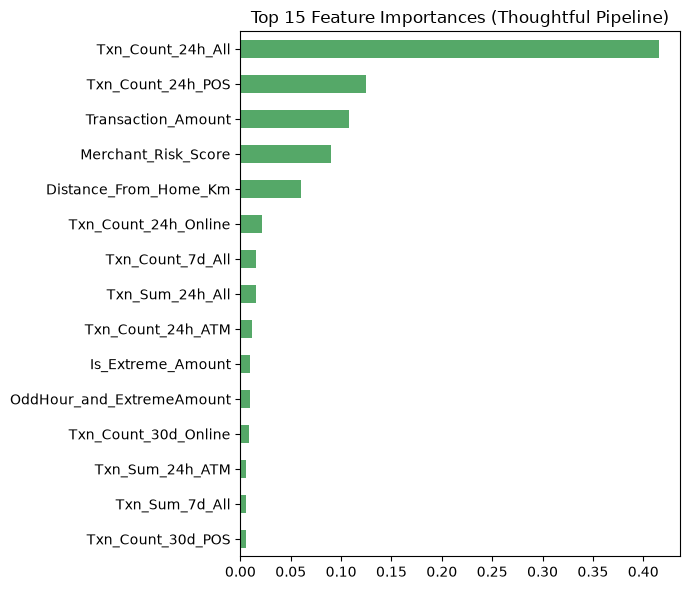

Txn_Count_24h_All            0.4157
Txn_Count_24h_POS            0.1248
Transaction_Amount           0.1077
Merchant_Risk_Score          0.0899
Distance_From_Home_Km        0.0598
Txn_Count_24h_Online         0.0218
Txn_Count_7d_All             0.0157
Txn_Sum_24h_All              0.0156
Txn_Count_24h_ATM            0.0115
Is_Extreme_Amount            0.0095
OddHour_and_ExtremeAmount    0.0095
Txn_Count_30d_Online         0.0081
Txn_Sum_24h_ATM              0.0058
Txn_Sum_7d_All               0.0058
Txn_Count_30d_POS            0.0054
dtype: float64

In [34]:
importance = pd.Series(gb_thoughtful.feature_importances_, index=Xt_train.columns)
top15 = importance.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 6))
top15.sort_values().plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Top 15 Feature Importances (Thoughtful Pipeline)")
plt.tight_layout()
plt.show()
top15.round(4)

## <font color="brown"> Business Insights and Recommendations</font>

- **The merge itself is a missingness mechanism, and a monitorable one.** 2,312 of 100,000
  customers (2.31%) had no `account_summary` row at merge time, concentrated almost entirely among
  customers onboarded in the last 30-90 days (17.3% missing vs. 0.1% for tenured customers). This
  is a data-pipeline sync lag, not randomness, worth tracking as a pipeline-health metric in its
  own right, not just patched over with imputation.

- **Missingness needs a mechanism-specific treatment, not one blanket rule.** 158 of 186 merged
  columns have some missingness, spanning 2.3% to 91.1%. Four distinct, verified mechanisms were
  found: MAR on `Account_Age_Days` (30d/90d transaction aggregates), MAR on `Customer_Since_Days`
  (the merge gap above), MNAR on `Annual_Income` (missing more for lower earners and
  harder-to-verify employment types, 10.9% for Salaried vs. 27.9% for Unemployed), and MCAR on the
  optional KYC fields (~80-91% missing, by design). Each got a different, defensible treatment:
  `_was_missing` indicators before imputing, group-aware medians, or an explicit "Missing"
  category, rather than one global rule applied everywhere.

- **Outliers in transaction amount are disproportionately fraud, not noise.** Just 9.6% of the
  training split sits in the extreme tails of `Transaction_Amount`, yet those rows contain 701 of
  1,258 training-set fraud cases (55.7% of all fraud). Blindly capping these "outliers" would have
  discarded most of the model's fraud signal. Treating extremity as a feature (`Is_Extreme_Amount`)
  instead of scrubbing it captures this cleanly: fraud rate is 12.16% among flagged transactions
  vs. 1.03% otherwise.

- **~190 raw columns is not ~190 independent signals.** 17 of the 120 transaction-window
  aggregate columns were dropped as redundant (pairwise correlation above 0.95, decided on the
  training split only) with no loss of information, a direct consequence of how rolling-window
  feature stores are built in practice.

- **Careful data preparation did not improve the Gradient Boosting model** (PR-AUC 0.724 vs. 0.732
  for the naive baseline, essentially a tie, naive even edges ahead slightly) **but did improve
  Logistic Regression** (PR-AUC 0.678 vs. 0.666, and every other metric moved the same direction).
  Tree ensembles are inherently robust to imputation choice, outlier scale, and can approximate
  interactions through splits; linear models can't. Don't assume data-cleaning effort pays off
  identically for every model family, verify it for the one actually being deployed.

- **The default 0.5 threshold is a poor operating point for this fraud rate.** It catches 91.9% of
  fraud but at only 29.4% precision, meaning roughly 7 of every 10 flagged transactions are false
  alarms for investigators to chase. Tuning the threshold on the validation set (to 0.94) trades
  recall down to 66.0% for precision up to 69.8%, improving F1 from 0.446 to 0.678. The bank should
  set its real operating threshold based on fraud-team investigation capacity, not the default.

- **The model leans on exactly the signals the business would expect**: 24-hour transaction
  velocity (`Txn_Count_24h_All`, `Txn_Count_24h_POS`), the transaction's own amount and merchant
  risk score, and distance from home dominate feature importance. The engineered
  `OddHour_and_ExtremeAmount` and `Is_Extreme_Amount` flags also place in the top 15, confirming
  they carry distinguishable signal even for a tree model, just not enough to move the aggregate
  metric on their own.

- **Recommendation**: keep the mechanism-aware missing-data and outlier treatment in production
  regardless of which model is deployed, it's defensible under model-risk review even when it
  doesn't move a tree ensemble's metrics, and it directly improves any interpretable/linear model
  the compliance team may require alongside it. Monitor the account-summary merge-omission rate as
  an operational signal, not just a modeling nuisance.